# The Buzz [Puzzle](https://substack.com/home/post/p-194477774)

**Rules**: players count up from 1, replacing any number with **"buzz"** when it is a multiple of 7 *or* contains the digit 7.

**Goal**: find the smallest N such that, from turn N onward, at least half of all numbers up to that point have been buzzed — and this remains true for every subsequent turn.

## Why the search stops at 10⁷

### Digit-7 density grows with the number of digits

For a $d$-digit number, the probability it contains **no** 7 is 

$$\left(\frac{9}{10}\right)^d$$

because each of its $d$ digits must avoid 7 (9 choices out of 10). So the fraction of $d$-digit numbers containing **at least one** 7 is :

$$1 - \left(\frac{9}{10}\right)^d$$

| d | fraction containing digit 7 |
|:-:|:---:|
| 5 | 40.9 % |
| 6 | 46.9 % |
| **7** | **52.2 %** |
| 8 | 56.9 % |

For $d = 7$: $\quad 1 - 0.9^7 \approx 52.2\% > 50\%$

This means that among all 7-digit numbers ($\geq 10^7$), **more than half** contain the digit 7 — before even counting multiples of 7.

### Consequence for the cumulative density

Once the **local** buzz density permanently exceeds 50 %, the **cumulative** density can only increase.
If the crossing point is found before $10^7$, it is guaranteed never to dip back below 50 % — no further checking needed.

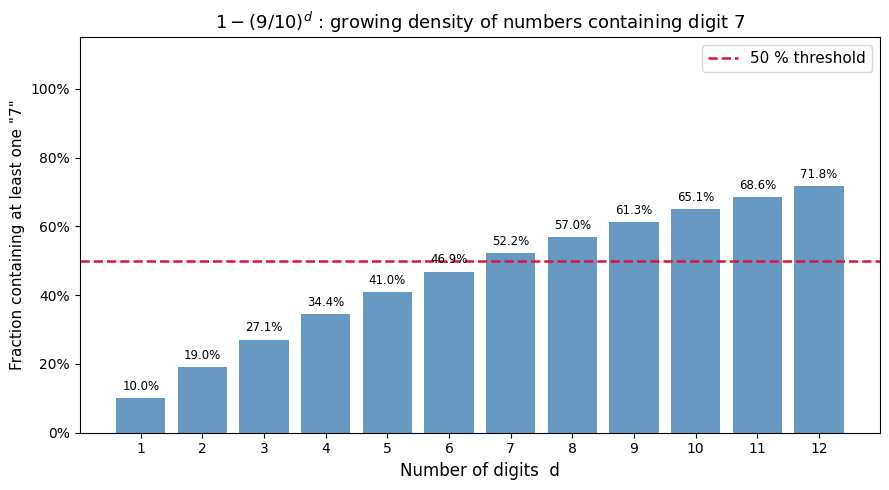

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

d_values = np.arange(1, 13)
density  = 1 - 0.9 ** d_values

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(d_values, density, color='steelblue', alpha=0.82)
ax.axhline(0.5, color='crimson', linestyle='--', linewidth=1.8, label='50 % threshold')

for d, v in zip(d_values, density):
    ax.text(d, v + 0.015, f'{v:.1%}', ha='center', va='bottom', fontsize=8.5)

ax.set_xlabel('Number of digits  d', fontsize=12)
ax.set_ylabel('Fraction containing at least one "7"', fontsize=11)
ax.set_title('$1 - (9/10)^d$ : growing density of numbers containing digit 7', fontsize=13)
ax.set_xticks(d_values)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

## Finding N — the algorithm

1. Sweep from 1 to $10^7$, recording the **last turn** where the cumulative density fell below 50 %.
2. From that last sub-50 % point, step forward one by one until the density first reaches or exceeds 50 %.
3. That turn is **N** — guaranteed to stay above 50 % forever, by the 7-digit argument above.

In [2]:
buzzes = 0

for n in range(1, 10**7 + 1):  # 10**7 is a safe upper bound from the 7-digit argument
    if '7' in str(n) or n % 7 == 0:
        buzzes += 1
    if buzzes / n < 0.5:
        last_below_n      = n
        last_below_buzzes = buzzes

n, buzzes = last_below_n, last_below_buzzes

while buzzes / n < 0.5:
    n += 1
    if '7' in str(n) or n % 7 == 0:
        buzzes += 1

print(f'N = {n:,}   |   buzzes up to N = {buzzes:,}   |   density = {buzzes / n:.6f}')

N = 708,588   |   buzzes up to N = 354,294   |   density = 0.500000


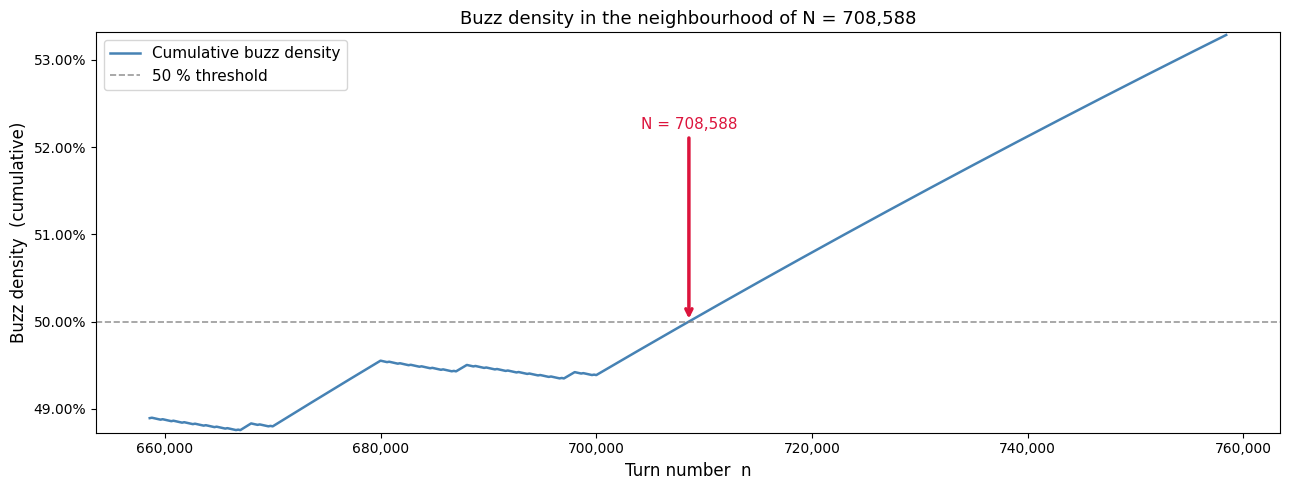

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SOLUTION_N = 708_588
WINDOW     = 50_000   # numbers shown on each side of N
STEP       = 200      # sampling interval for the plot

# Collect cumulative density in [SOLUTION_N - WINDOW, SOLUTION_N + WINDOW]
stop   = SOLUTION_N + WINDOW
buzzes = 0
ns, densities = [], []

for n in range(1, stop + 1):
    if '7' in str(n) or n % 7 == 0:
        buzzes += 1
    if n >= SOLUTION_N - WINDOW and n % STEP == 0:
        ns.append(n)
        densities.append(buzzes / n)

# Plot
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(ns, densities, color='steelblue', linewidth=1.8, label='Cumulative buzz density')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, alpha=0.8,
           label='50 % threshold')

y_lo = min(densities) - 0.0003
y_hi = max(densities) + 0.0003
ax.set_ylim(y_lo, y_hi)

arrow_start_y = y_lo + (y_hi - y_lo) * 0.75
ax.annotate(
    f'N = {SOLUTION_N:,}',
    xy=(SOLUTION_N, 0.5),
    xytext=(SOLUTION_N, arrow_start_y),
    fontsize=11, color='crimson', ha='center', va='bottom',
    arrowprops=dict(arrowstyle='->', color='crimson', lw=2.5),
)

ax.set_xlabel('Turn number  n', fontsize=12)
ax.set_ylabel('Buzz density  (cumulative)', fontsize=12)
ax.set_title(f'Buzz density in the neighbourhood of N = {SOLUTION_N:,}', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))

plt.tight_layout()
plt.show()